In [1]:
# ==============================
# Step 1: Import libraries
# ==============================
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Step 2: Download YOLOv5 ONNX model (Updated Stable Link)
# ==============================
if not os.path.exists("yolov5n.onnx"):
    print("Downloading YOLOv5n ONNX model...")
    # v7.0 is the latest stable release for YOLOv5 ONNX
    !curl -L -o yolov5n.onnx https://github.com/ultralytics/yolov5/releases/download/v7.0/yolov5n.onnx

# ==============================
# Step 3: Download COCO classes
# ==============================
if not os.path.exists("coco.names"):
    print("Downloading COCO class names...")
    !curl -L -o coco.names https://raw.githubusercontent.com/pjreddie/darknet/master/data/coco.names

# ==============================
# Step 4: Load class names
# ==============================
with open("coco.names", "r") as f:
    classes = f.read().strip().split("\n")

print(f"✅ Total Classes: {len(classes)}")
print(f"✅ First 10 Classes: {classes[:10]}")

# ==============================
# Step 5: Load YOLO model using OpenCV DNN
# ==============================
try:
    net = cv2.dnn.readNet("yolov5n.onnx")
    print("✅ YOLOv5n ONNX Model Loaded Successfully into OpenCV!")
except Exception as e:
    print(f"❌ Error loading model: {e}")

✅ Total Classes: 80
✅ First 10 Classes: ['person', 'bicycle', 'car', 'motorbike', 'aeroplane', 'bus', 'train', 'truck', 'boat', 'traffic light']
✅ YOLOv5n ONNX Model Loaded Successfully into OpenCV!


In [18]:
# ==============================
# YOLO CONFIG
# ==============================

INPUT_WIDTH = 640
INPUT_HEIGHT = 640

OBJECT_SCORE_THRESHOLD = 0.25
CLASS_SCORE_THRESHOLD = 0.25
NMS_THRESHOLD = 0.45

BOX_COLOR = (0,255,0)
THICKNESS = 2


# ==============================
# Draw label
# ==============================

def draw_label(image, label, x, y):

    font = cv2.FONT_HERSHEY_SIMPLEX
    scale = 0.5
    thickness = 1

    (w,h), _ = cv2.getTextSize(label, font, scale, thickness)

    cv2.rectangle(image,(x,y),(x+w,y-h),(255,255,255),-1)

    cv2.putText(image,label,(x,y),font,scale,(0,0,0),thickness)



# ==============================
# Forward Pass
# ==============================

def yolo_forward(image):

    blob = cv2.dnn.blobFromImage(
        image,
        1/255.0,
        (INPUT_WIDTH,INPUT_HEIGHT),
        swapRB=True,
        crop=False
    )

    net.setInput(blob)

    outputs = net.forward()

    return outputs



# ==============================
# Post Processing
# ==============================

def post_process(image, outputs):

    boxes = []
    confidences = []
    class_ids = []

    rows = outputs[0].shape[0]

    img_h, img_w = image.shape[:2]

    x_factor = img_w / INPUT_WIDTH
    y_factor = img_h / INPUT_HEIGHT


    for r in range(rows):

        row = outputs[0][r]

        objectness = row[4]

        if objectness >= OBJECT_SCORE_THRESHOLD:

            scores = row[5:]

            class_id = np.argmax(scores)

            class_score = scores[class_id]

            confidence = objectness * class_score

            if confidence >= CLASS_SCORE_THRESHOLD:

                confidences.append(float(confidence))
                class_ids.append(class_id)

                cx, cy, w, h = row[0], row[1], row[2], row[3]

                left = int((cx - w/2) * x_factor)
                top = int((cy - h/2) * y_factor)

                width = int(w * x_factor)
                height = int(h * y_factor)

                boxes.append([left, top, width, height])


    # ==============================
    # Non Max Suppression
    # ==============================

    indices = cv2.dnn.NMSBoxes(
        boxes,
        confidences,
        CLASS_SCORE_THRESHOLD,
        NMS_THRESHOLD
    )


    # ==============================
    # Draw final boxes
    # ==============================

    if len(indices) > 0:

        for i in indices.flatten():

            left, top, width, height = boxes[i]

            cv2.rectangle(
                image,
                (left, top),
                (left + width, top + height),
                BOX_COLOR,
                THICKNESS
            )

            label = "{}:{:.2f}".format(classes[class_ids[i]], confidences[i])

            draw_label(image, label, left, top)


    return image

(-0.5, 1279.5, 719.5, -0.5)

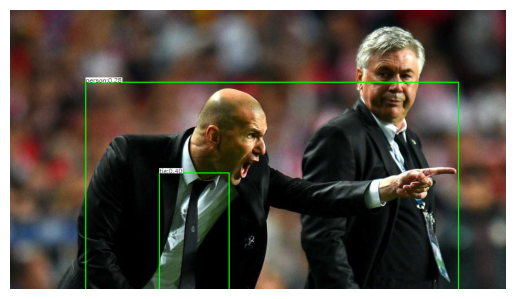

In [19]:
image = cv2.imread("test.jpg")

outputs = yolo_forward(image)

result = post_process(image,outputs)

plt.imshow(cv2.cvtColor(result,cv2.COLOR_BGR2RGB))
plt.axis("off")

In [20]:
import urllib.request

url = "https://ultralytics.com/images/zidane.jpg"

urllib.request.urlretrieve(url, "test.jpg")

print("Image downloaded successfully")

Image downloaded successfully


In [22]:
import urllib.request

url = "https://images.unsplash.com/photo-1502877338535-766e1452684a"

urllib.request.urlretrieve(url, "street.jpg")

print("Image downloaded")

Image downloaded


(-0.5, 5858.5, 3900.5, -0.5)

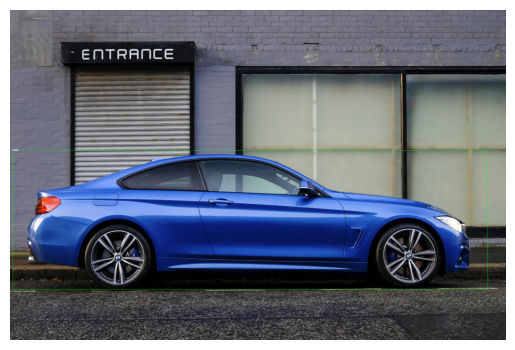

In [23]:
image = cv2.imread("street.jpg")

outputs = yolo_forward(image)

result = post_process(image, outputs)

plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.axis("off")

In [26]:
import urllib.request

url = "https://ultralytics.com/images/bus.jpg"

urllib.request.urlretrieve(url,"multi1.jpg")

('multi1.jpg', <http.client.HTTPMessage at 0x256097bea50>)

(-0.5, 809.5, 1079.5, -0.5)

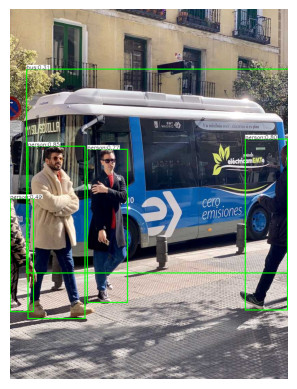

In [27]:
image = cv2.imread("multi1.jpg")

outputs = yolo_forward(image)

result = post_process(image, outputs)

plt.imshow(cv2.cvtColor(result,cv2.COLOR_BGR2RGB))
plt.axis("off")